# 🛠️ Preparación de los Datos

In [6]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y DEPENDENCIAS
# ==========================================

# Manipulación de datos y matemáticas
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de datos (Scikit-Learn)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de Evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:

ruta_archivo = '/content/telecom_limpio.csv'

# Cargamos el archivo CSV
df = pd.read_csv(ruta_archivo)

# Verificamos rápidamente la estructura para asegurar que todo está en orden
print("Información de las columnas y tipos de datos:")
df.info()

print("\nPrimeras 5 filas del dataset:")
df.head()

Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   float64
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   float64
 12  DeviceProtection  7267 non-null   float64
 13  TechSupport       7267 non-null   float64
 14  StreamingTV       7267 non-null   float64
 15  StreamingMovies   7267 non-null   float64
 

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [9]:
# ==========================================
# 2. ELIMINACIÓN DE COLUMNAS IRRELEVANTES
# ==========================================

# Eliminamos la columna customerID porque no aporta valor predictivo
df = df.drop('customerID', axis=1)

# Verificamos que se haya eliminado correctamente
print(f"El dataset ahora tiene {df.shape[1]} columnas.")
print("Columnas actuales:", df.columns.tolist())

El dataset ahora tiene 21 columnas.
Columnas actuales: ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']


In [11]:
# ==========================================
# 3. ENCODING (Codificación de Variables Categóricas)
# ==========================================

# Identificamos automaticamente todas las columnas que son del tipo texto ('object)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas a codificar: {columnas_categoricas}")

# Aplicamos One-Hot-Encoding
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# Verificamos cómo quedo nuestro dataset
print(f"\nTransformación exitosa. El dataset pasó de {df.shape[1]} a {df_encoded.shape[1]} columnas.")

# Vemos las primeras 5 filas para confirmar que todo es numérico
df_encoded.head()

Columnas a codificar: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'Contract', 'PaymentMethod']

Transformación exitosa. El dataset pasó de 21 a 27 columnas.


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,1.0,0.0,1.0,1.0,...,0,0,0,0,0,1,0,0,0,1
1,0.0,0,0,0,9,1,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,1.0,0,0,0,4,1,0.0,1.0,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
3,1.0,1,1,0,13,1,1.0,1.0,0.0,1.0,...,0,1,0,0,0,0,0,0,1,0
4,1.0,1,1,0,3,1,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,0,1


Conteo absoluto de la variable objetivo:
Churn
0.0    5398
1.0    1869
Name: count, dtype: int64

Proporción de clases (%):
Churn
0.0    74.28
1.0    25.72
Name: proportion, dtype: float64


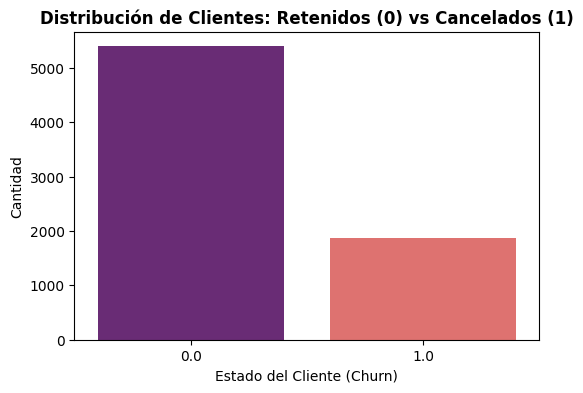

In [14]:
# ==========================================
# 4. VERIFICACIÓN DE BALANCE DE CLASES (CHURN)
# ==========================================

# Conteo absoluto
conteo_churn = df_encoded['Churn'].value_counts()
print("Conteo absoluto de la variable objetivo:")
print(conteo_churn)

# Proporción en porcentaje
proporcion_churn = df_encoded['Churn'].value_counts(normalize=True) * 100
print("\nProporción de clases (%):")
print(proporcion_churn.round(2))

# Visualización rápida del desbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df_encoded, x='Churn', hue='Churn', palette='magma', legend=False)
plt.title('Distribución de Clientes: Retenidos (0) vs Cancelados (1)', fontweight='bold')
plt.xlabel('Estado del Cliente (Churn)')
plt.ylabel('Cantidad')
plt.show()

In [15]:
# ==========================================
# 5. BALANCEO DE CLASES CON SMOTE
# ==========================================

# Importamos la libreria para SMOTE
from imblearn.over_sampling import SMOTE

# Separamos las características (X) y la variable a predecir (y)
X= df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Inicializamos SMOTE con una semilla aleatoria para que sus resultados sean replicables
smote = SMOTE(random_state=42)

#Aplicamos el balanceo
X_balanceado, y_balanceado = smote.fit_resample(X, y)

#Comprobamos los resultados

print("Distribución ANTES de SMOTE:")
print(y.value_counts())

print("\nDistribución DESPUÉS de SMOTE:")
print(y_balanceado.value_counts())

Distribución ANTES de SMOTE:
Churn
0.0    5398
1.0    1869
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Churn
0.0    5398
1.0    5398
Name: count, dtype: int64


#🎯 Correlación y Selección de Variables

Top 5 factores que EMPUJAN a cancelar (+):
InternetService_Fiber optic       0.300949
PaymentMethod_Electronic check    0.294626
Cuentas_Diarias                   0.189918
Charges.Monthly                   0.189866
PaperlessBilling                  0.186666
Name: Churn, dtype: float64

Top 5 factores que EVITAN la cancelación (-):
Charges.Total                        -0.193345
InternetService_No                   -0.224051
OnlineSecurity_No internet service   -0.224051
Contract_Two year                    -0.295138
tenure                               -0.344079
Name: Churn, dtype: float64


/tmp/ipykernel_155/2484334253.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values[1:], y=correlaciones.index[1:], palette='coolwarm')


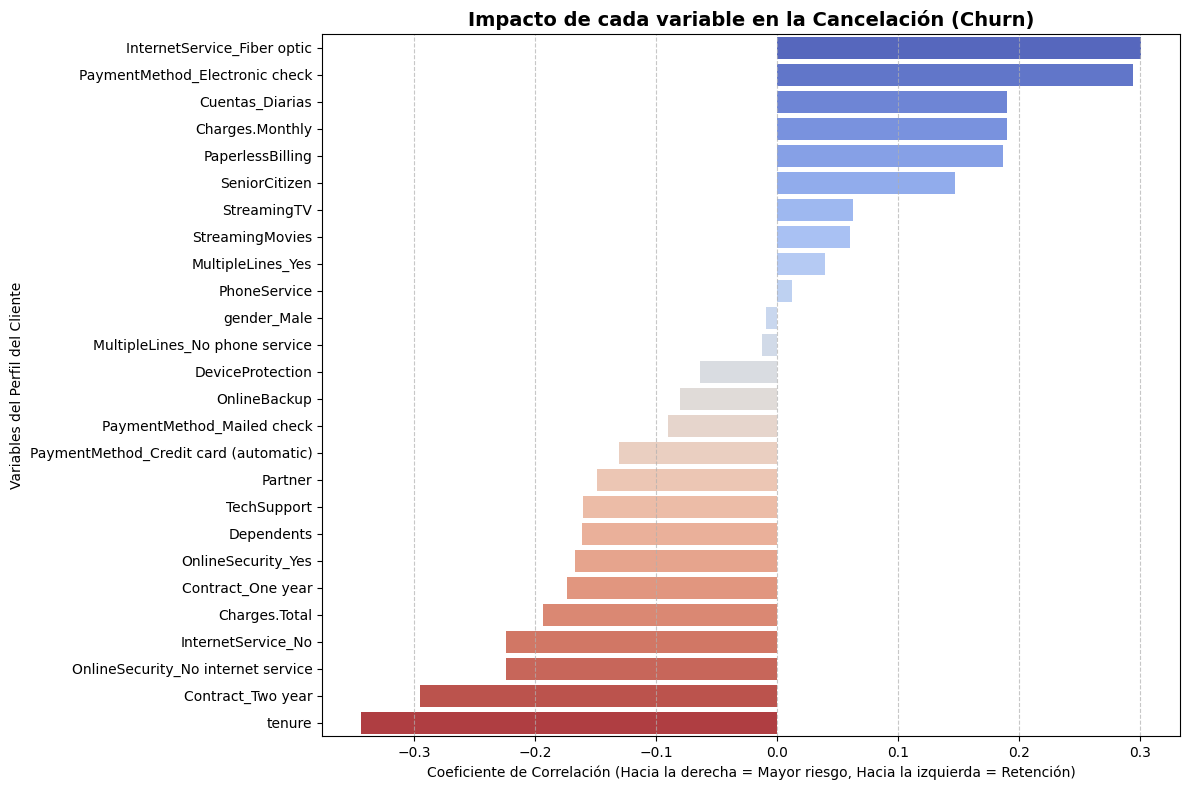

In [17]:
# ==========================================
# 6. ANÁLISIS DE CORRELACIÓN CON CHURN
# ==========================================

# Calculamos la correlación de todas las variables
correlaciones = df_encoded.corr()['Churn'].sort_values(ascending=False)

# Mostramos el top 5 positivo y el top 5 negativo en texto
print("Top 5 factores que EMPUJAN a cancelar (+):")
print(correlaciones[1:6])

print("\nTop 5 factores que EVITAN la cancelación (-):")
print(correlaciones[-5:])

# Graficamos las correlaciones para una lectura más sencilla

plt.figure(figsize=(12, 8))

sns.barplot(x=correlaciones.values[1:], y=correlaciones.index[1:], palette='coolwarm')

plt.title('Impacto de cada variable en la Cancelación (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación (Hacia la derecha = Mayor riesgo, Hacia la izquierda = Retención)')
plt.ylabel('Variables del Perfil del Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

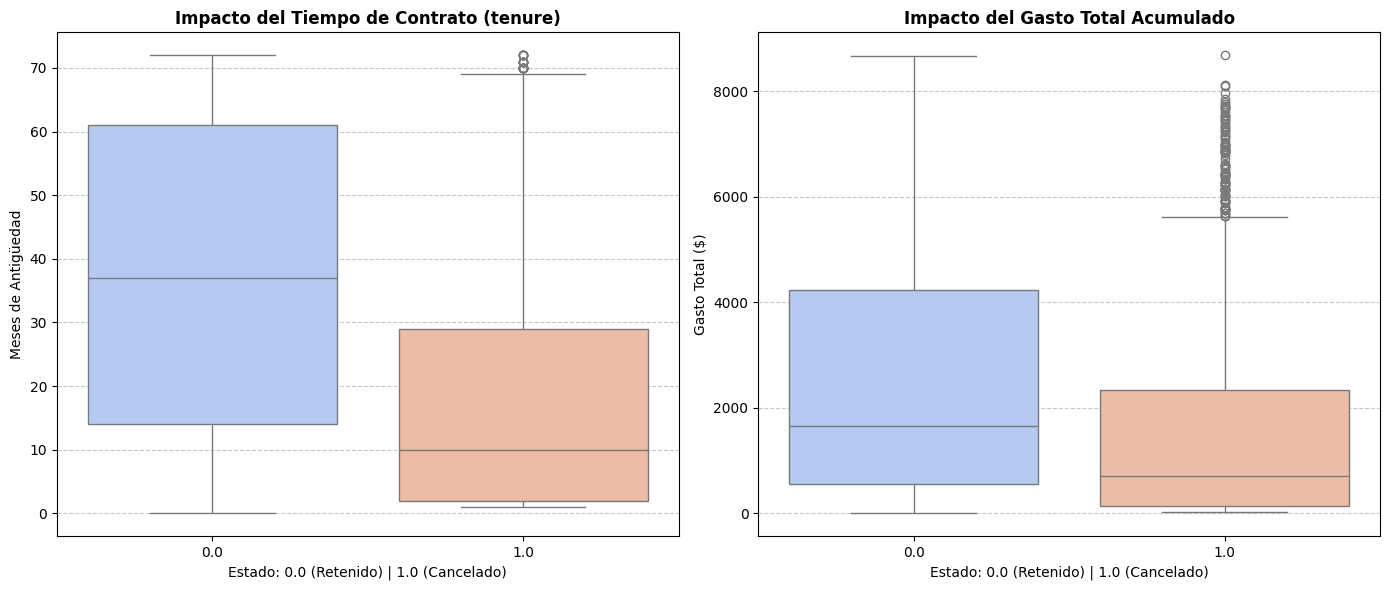

In [18]:
# ==========================================
# 7. ANÁLISIS DIRIGIDO (Variables Clave vs Churn)
# ==========================================

plt.figure(figsize=(14, 6))

# Gráfico Tiempo de contrato (tenure) vs Cancelación
plt.subplot(1, 2, 1)

sns.boxplot(data=df_encoded, x='Churn', y='tenure', hue='Churn', palette='coolwarm', legend=False)
plt.title('Impacto del Tiempo de Contrato (tenure)', fontsize=12, fontweight='bold')
plt.xlabel('Estado: 0.0 (Retenido) | 1.0 (Cancelado)')
plt.ylabel('Meses de Antigüedad')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico Gasto total (Charges.Total) vs Cancelación
plt.subplot(1, 2, 2)
sns.boxplot(data=df_encoded, x='Churn', y='Charges.Total', hue='Churn', palette='coolwarm', legend=False)
plt.title('Impacto del Gasto Total Acumulado', fontsize=12, fontweight='bold')
plt.xlabel('Estado: 0.0 (Retenido) | 1.0 (Cancelado)')
plt.ylabel('Gasto Total ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

In [20]:
# ==========================================
# 8. SEPARACIÓN DE DATOS (TRAIN / TEST)
# ==========================================

# Usaremos X_balanceado y y_balanceado
# test_size=0.20 asigna el 20% de los datos para probar el desempeño
# random_state=42 asegura que la división sea exactamente la misma cada vez que ejecutemos el código

X_train, X_test, y_train, y_test = train_test_split(
    X_balanceado,
    y_balanceado,
    test_size=0.20,
    random_state=42
)

#Comprobamos como a quedado la división
print(f"Total de datos disponibles: {X_balanceado.shape[0]} filas")
print(f"Datos para ENTRENAR (80%): {X_train.shape[0]} filas")
print(f"Datos para PROBAR (20%): {X_test.shape[0]} filas")

Total de datos disponibles: 10796 filas
Datos para ENTRENAR (80%): 8636 filas
Datos para PROBAR (20%): 2160 filas


In [24]:
# ==========================================
# 9. NORMALIZACIÓN Y ENTRENAMIENTO DE MODELOS
# ==========================================

# Inciamos el eslador
scaler = StandardScaler()

# Ajustamos y transformamos solo los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los datos de prueba
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados correctamente para modelos sensibles a la escala.\n")

# Modelo 1 Regresión logistica
print("Entrenando Modelo 1: Regresión logistica...")

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
print("Regresión logistica lista.")

# Modelo 2 Random forest
print("\nEntrenando Modelo 2: Random forest...")

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
print("Random forest lista.")

Datos normalizados correctamente para modelos sensibles a la escala.

Entrenando Modelo 1: Regresión logistica...
Regresión logistica lista.

Entrenando Modelo 2: Random forest...
Random forest lista.


RESULTADOS: REGRESIÓN LOGÍSTICA
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.83      0.76      0.80      1060
         1.0       0.79      0.85      0.82      1100

    accuracy                           0.81      2160
   macro avg       0.81      0.81      0.81      2160
weighted avg       0.81      0.81      0.81      2160


 RESULTADOS: RANDOM FOREST
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.84      0.83      0.84      1060
         1.0       0.84      0.85      0.84      1100

    accuracy                           0.84      2160
   macro avg       0.84      0.84      0.84      2160
weighted avg       0.84      0.84      0.84      2160



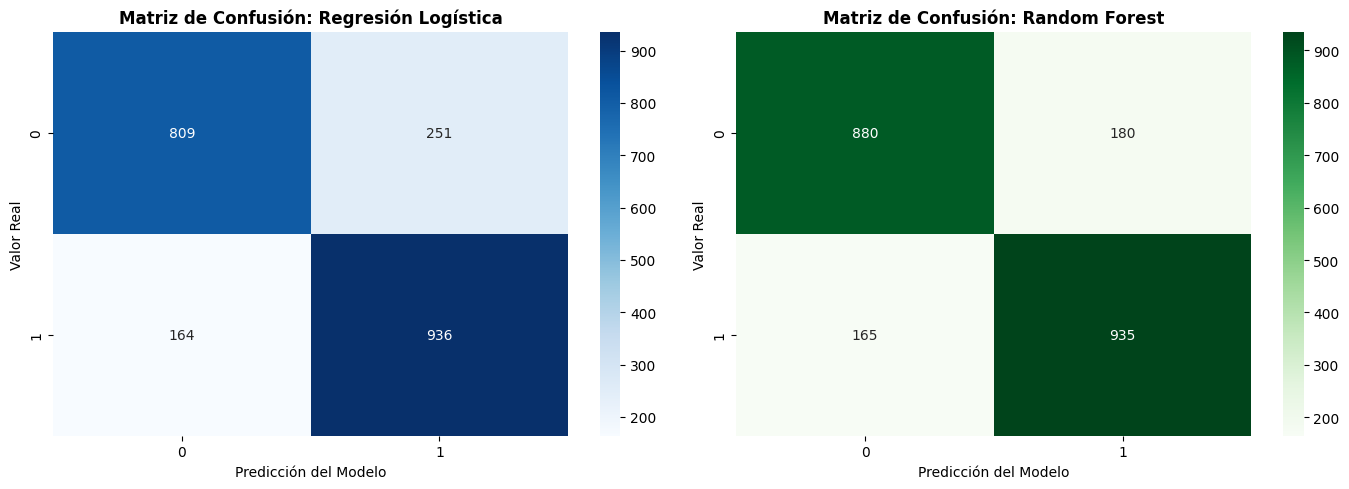

In [25]:
# ==========================================
# 10. EVALUACIÓN DE LOS MODELOS
# ==========================================

# Predicciones en el conjunto de prueba
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

# Reporte de metricas
print("RESULTADOS: REGRESIÓN LOGÍSTICA")
print("-" * 50)
print(classification_report(y_test, y_pred_lr))

print("\n RESULTADOS: RANDOM FOREST")
print("-" * 50)
print(classification_report(y_test, y_pred_rf))

# Matrices de confusión visuales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz para Regresión Logística (Azul)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontweight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real')

# Matriz para Random Forest (Verde)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión: Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# 📋 Interpretación y Conclusiones

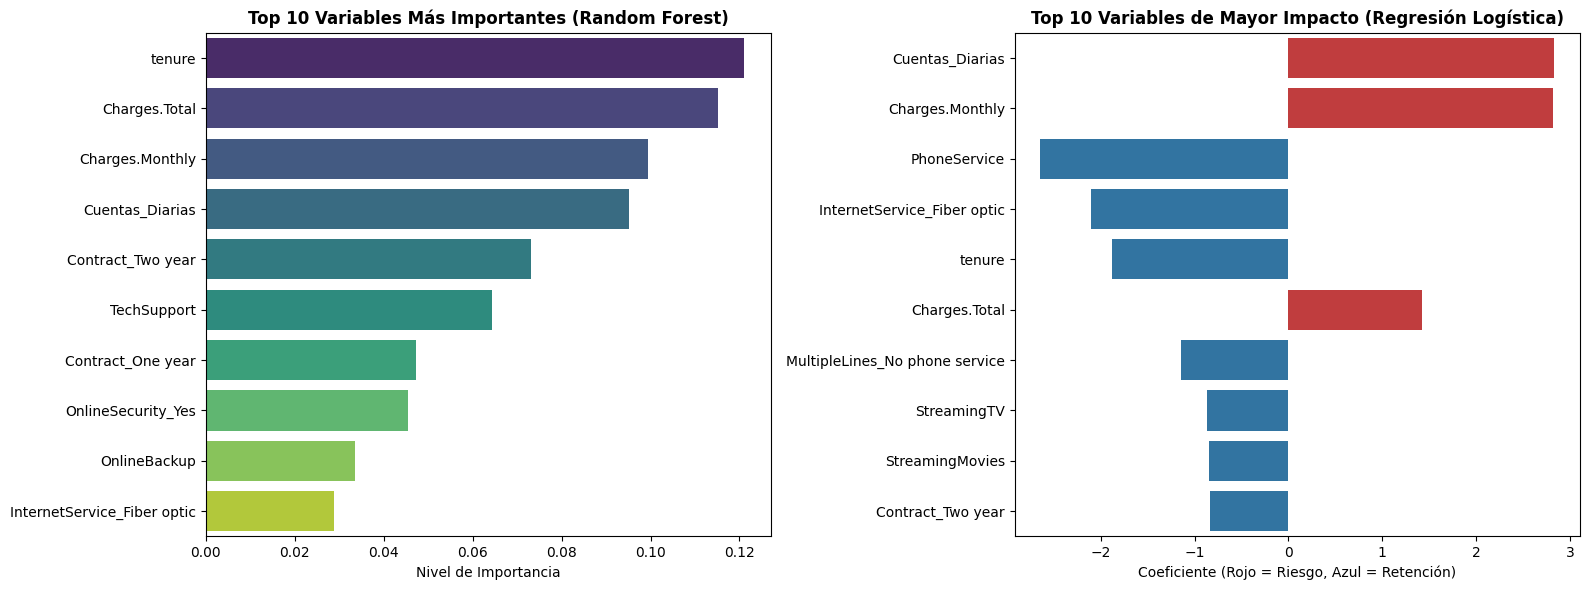

In [27]:
# ==========================================
# 11. ANÁLISIS DE IMPORTANCIA DE VARIABLES
# ==========================================

# Obtenemos los nombres de las columnas
caracteristicas = X_train.columns

# --- Importancia en Random Forest ---
importancia_rf = modelo_rf.feature_importances_
df_rf_imp = pd.DataFrame({'Variable': caracteristicas, 'Importancia': importancia_rf})
# Ordenamos de mayor a menor importancia y tomamos el Top 10
df_rf_imp = df_rf_imp.sort_values(by='Importancia', ascending=False).head(10)

# --- Coeficientes en Regresión Logística ---
coeficientes_lr = modelo_lr.coef_[0]
df_lr_coef = pd.DataFrame({'Variable': caracteristicas, 'Coeficiente': coeficientes_lr})
# Usamos el valor absoluto para ver el impacto total (positivo o negativo) y tomamos el Top 10
df_lr_coef['Impacto_Absoluto'] = df_lr_coef['Coeficiente'].abs()
df_lr_coef = df_lr_coef.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Random Forest
sns.barplot(
    x='Importancia',
    y='Variable',
    hue='Variable',
    data=df_rf_imp,
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 10 Variables Más Importantes (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Nivel de Importancia')
axes[0].set_ylabel('')

# Gráfico 2: Regresión Logística
colores_lr = ['#d62728' if x > 0 else '#1f77b4' for x in df_lr_coef['Coeficiente']]
sns.barplot(
    x='Coeficiente',
    y='Variable',
    hue='Variable',
    data=df_lr_coef,
    palette=colores_lr,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 10 Variables de Mayor Impacto (Regresión Logística)', fontweight='bold')
axes[1].set_xlabel('Coeficiente (Rojo = Riesgo, Azul = Retención)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Informe Final: Predicción de Evasión de Clientes (Machine Learning)

## Introducción.

En esta segunda fase, el objetivo principal fue ir un paso más allá del análisis histórico y desarrollar modelos predictivos utilizando Inteligencia Artificial. Buscamos crear un algoritmo capaz de prever con anticipación qué clientes tienen mayor probabilidad de cancelar su suscripción (churn), permitiendo a Telecom X pasar de una postura reactiva a una estrategia de retención proactiva.

## Preparación de datos para Machine Learning.

Para que los algoritmos matemáticos pudieran aprender correctamente de los clientes, se preparó el terreno con los siguientes pasos:

* Limpieza de identificadores: Se eliminó la columna customerID, ya que es un dato único que no aporta patrones de comportamiento y podría confundir al modelo.

* Transformación a formato numérico (Encoding): Los algoritmos no entienden palabras. Transformamos todas las variables de texto (como el tipo de contrato o el género) en columnas con valores de 0 y 1 para hacerlas compatibles con los cálculos matemáticos.

* Balanceo de datos (SMOTE): Como naturalmente hay más clientes leales que clientes que cancelan, se crearon datos sintéticos para igualar la balanza a un 50/50. Esto aseguró que el modelo aprendiera a detectar a los desertores con la misma eficacia que a los clientes que se quedan.

## Entrenamiento y Evaluación de Modelos.

Para evaluar el rendimiento real de nuestra solución, dividimos los datos: el modelo usó el 80% para estudiar y aprender patrones, y el 20% restante se ocultó para hacerle un "examen final".
Se entrenaron dos modelos distintos para comparar su eficacia:

* Regresión Logística: Un modelo matemático tradicional (requirió normalización de los datos).

* Random Forest (Bosques Aleatorios): Un modelo basado en cientos de árboles de decisión.

## Conclusiones e Insights.

A partir de las evaluaciones, se obtuvieron los siguientes resultados clave:

* El modelo ganador es Random Forest: Logró una exactitud global del 84% en el examen de prueba. Lo más importante es que demostró una excelente capacidad para detectar clientes en riesgo real, reduciendo las "falsas alarmas".

* El algoritmo confirma la teoría: Al pedirle al modelo que nos revelara qué factores usó para tomar sus decisiones, el top 3 de variables más importantes fueron: la antigüedad del cliente (tenure), el impacto de su factura mensual (Charges.Monthly) y el gasto total acumulado.

## Recomendaciones Estratégicas.

Con este modelo predictivo listo para ser implementado, se sugieren las siguientes acciones para Telecom X:

* Alertas automatizadas de retención: Conectar este modelo a la base de datos de la empresa para que emita una "alerta roja" automática cuando un cliente alcance un umbral alto de riesgo.

* Intervención enfocada en la tarifa: Sabiendo que el cargo mensual es un motor de cancelación para el modelo, el equipo de retención debe contactar proactivamente a los clientes marcados en riesgo ofreciendo ajustes de plan o beneficios extra antes de que tomen la decisión de irse.

* Reforzar el escudo de los primeros meses: Dado que la antigüedad (tenure) es la variable que más peso tiene para predecir si alguien se queda o se va, es vital invertir fuertemente en la experiencia del cliente durante sus primeros 90 días para garantizar su lealtad a largo plazo.